In [37]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [38]:
# ── 通道定義 & 五腦區分組 ──
CH_NAMES = [
    'Fp1','Fz','F3','F7','FT9','FC5','FC1',
    'C3','T7','TP9','CP5','CP1','Pz','P3','P7',
    'O1','Oz','O2',
    'P4','P8','TP10','CP6','CP2','Cz','C4','T8',
    'FT10','FC6','FC2','F4','F8','Fp2'
]
SESSION_NAMES = ['ss01', 'ss02', 'ss03']

REGIONS = {
    'Frontal':   [0, 31, 2, 29, 3, 30, 1],               # Fp1,Fp2,F3,F4,F7,F8,Fz (7ch)
    'Central':   [7, 24, 23, 6, 28, 5, 27],               # C3,C4,Cz,FC1,FC2,FC5,FC6 (7ch)
    'Parietal':  [13, 18, 14, 19, 12, 11, 22, 10, 21],    # P3,P4,P7,P8,Pz,CP1,CP2,CP5,CP6 (9ch)
    'Temporal':  [8, 25, 4, 26, 9, 20],                   # T7,T8,FT9,FT10,TP9,TP10 (6ch)
    'Occipital': [15, 17, 16],                             # O1,O2,Oz (3ch)
}

for name, chs in REGIONS.items():
    ch_names = [CH_NAMES[i] for i in chs]
    print(f'{name} ({len(chs)}ch): {ch_names}')

Frontal (7ch): ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz']
Central (7ch): ['C3', 'C4', 'Cz', 'FC1', 'FC2', 'FC5', 'FC6']
Parietal (9ch): ['P3', 'P4', 'P7', 'P8', 'Pz', 'CP1', 'CP2', 'CP5', 'CP6']
Temporal (6ch): ['T7', 'T8', 'FT9', 'FT10', 'TP9', 'TP10']
Occipital (3ch): ['O1', 'O2', 'Oz']


In [39]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026'
BASE_MASTER  = r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in ['ss01','ss02','ss03']},
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['amateur', 'master', 'prof']:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f'[{group}] 完整 subject：{len(complete[group])} 人')

print('\n載入資料...')
X_a1, X_a2, X_a3 = load_group(*maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print(f'完成  shape: {X_a1.shape}  (n_sub, 32ch, 39time, 5bands)')

[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入資料...
完成  shape: (28, 32, 39, 5)  (n_sub, 32ch, 39time, 5bands)


In [40]:
# ── 特徵提取 (與 svm_region4_loso.ipynb 完全一致) ──

CLASS_NAMES = ['amateur', 'master', 'prof']

def extract_mean_3d(X):
    """(n, 32ch, 39time, 5bands) → (n, 32, 5)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]
    return X.mean(axis=2)

n_a = len(complete['amateur'])
n_m = len(complete['master'])
n_p = len(complete['prof'])
n_total = n_a + n_m + n_p

raw = {
    'amateur': [X_a1, X_a2, X_a3],
    'master':  [X_m1, X_m2, X_m3],
    'prof':    [X_p1, X_p2, X_p3],
}

# 與 svm_region4_loso.ipynb 相同排列：
# amateur_ss01, amateur_ss02, amateur_ss03, master_ss01, ..., prof_ss03
feats_3d = []
for g in CLASS_NAMES:
    for Xr in raw[g]:
        feats_3d.append(extract_mean_3d(Xr))
X_3d = np.vstack(feats_3d)  # (168, 32, 5)

y_all = np.concatenate([np.zeros(n_a * 3), np.ones(n_m * 3), np.full(n_p * 3, 2)])
subject_ids = complete['amateur'] + complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['amateur'], 3),
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])
subject_labels = {}
for g_idx, g in enumerate(CLASS_NAMES):
    for s in complete[g]:
        subject_labels[s] = g_idx

# 同時保留 per-session 結構 (方便擾動用)
# feats_3d_by_session[ss_idx] = (n_total, 32, 5)，subject 順序同 subject_ids
raw_by_session = [
    [X_a1, X_m1, X_p1],  # ss01
    [X_a2, X_m2, X_p2],  # ss02
    [X_a3, X_m3, X_p3],  # ss03
]
feats_3d_by_session = []
for ss_idx in range(3):
    parts = [extract_mean_3d(Xr) for Xr in raw_by_session[ss_idx]]
    feats_3d_by_session.append(np.vstack(parts))  # (56, 32, 5)

print(f'X_3d shape: {X_3d.shape}')
print(f'feats_3d_by_session: 3 × {feats_3d_by_session[0].shape}')
print(f'Total subjects: {n_total}  (Amateur: {n_a}, Master: {n_m}, Prof: {n_p})')

X_3d shape: (168, 32, 5)
feats_3d_by_session: 3 × (56, 32, 5)
Total subjects: 56  (Amateur: 28, Master: 20, Prof: 8)


In [41]:
# ── LOSO 函式 (與 svm_region4_loso.ipynb 一致) ──

def run_loso(X_3d, ch_idx, y_all, subject_split, subject_ids, subject_labels):
    """
    X_3d: (168, 32, 5)  排列為 group-then-session
    """
    n_ch = len(ch_idx)
    dims = n_ch * 5
    pca_n = min(40, dims)

    X_feat = X_3d[:, ch_idx, :].reshape(len(X_3d), -1)

    all_preds, all_true = [], []
    per_sub = []

    for test_subject in subject_ids:
        test_mask  = subject_split == test_subject
        train_mask = ~test_mask

        X_tr, y_tr = X_feat[train_mask], y_all[train_mask].astype(int)
        X_te, y_te = X_feat[test_mask],  y_all[test_mask].astype(int)

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=pca_n)),
            ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                           class_weight='balanced', random_state=42)),
        ])
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_te)

        acc = accuracy_score(y_te, preds)
        f1  = f1_score(y_te, preds, average='macro', zero_division=0)
        per_sub.append({'acc': acc, 'f1': f1, 'subject': test_subject,
                        'true': subject_labels[test_subject]})
        all_preds.extend(preds)
        all_true.extend(y_te)

    all_preds = np.array(all_preds)
    all_true  = np.array(all_true)
    mean_acc = np.mean([r['acc'] for r in per_sub])
    mean_f1  = np.mean([r['f1']  for r in per_sub])
    return mean_acc, mean_f1, per_sub, all_preds, all_true

In [42]:
# ── Baseline (每個腦區，與 svm_region4_loso.ipynb 結果一致) ──

baseline = {}
for region_name, ch_idx in REGIONS.items():
    acc, f1, per_sub, preds, true = run_loso(
        X_3d, ch_idx, y_all, subject_split, subject_ids, subject_labels
    )
    baseline[region_name] = {'acc': acc, 'f1': f1, 'per_sub': per_sub,
                             'preds': preds, 'true': true}
    n_ch = len(ch_idx)
    print(f'[{region_name:<13s}] {n_ch:2d}ch  Baseline  Acc={acc:.3f}  F1={f1:.3f}')

[Frontal      ]  7ch  Baseline  Acc=0.679  F1=0.550
[Central      ]  7ch  Baseline  Acc=0.649  F1=0.493
[Parietal     ]  9ch  Baseline  Acc=0.756  F1=0.635
[Temporal     ]  6ch  Baseline  Acc=0.589  F1=0.444
[Occipital    ]  3ch  Baseline  Acc=0.565  F1=0.422


In [43]:
# ── 輔助函式：從 per-session 特徵重建 svm_region4_loso 排列 ──

def build_X3d_from_sessions(feats_sessions, n_a, n_m, n_p):
    """
    feats_sessions: list of 3 arrays, each (n_total, 32, 5)
        subject 順序: amateur (0:n_a), master (n_a:n_a+n_m), prof (n_a+n_m:)
    回傳: (168, 32, 5)，排列為 svm_region4_loso 的方式
        amateur_ss01, amateur_ss02, amateur_ss03, master_ss01, ..., prof_ss03
    """
    parts = []
    group_slices = [(0, n_a), (n_a, n_a + n_m), (n_a + n_m, n_a + n_m + n_p)]
    for g_start, g_end in group_slices:
        for ss_idx in range(3):
            parts.append(feats_sessions[ss_idx][g_start:g_end])
    return np.vstack(parts)

In [44]:
# ── Session 擾動實驗 (每個腦區 × 每個 session) ──

N_REPEATS = 30

perturb_results = {}

for region_name, ch_idx in REGIONS.items():
    perturb_results[region_name] = {}
    print(f'\n── {region_name} ({len(ch_idx)}ch) ──')

    for ss_idx in range(3):
        accs, f1s = [], []
        for seed in range(N_REPEATS):
            rng = np.random.RandomState(seed)
            perturbed = [f.copy() for f in feats_3d_by_session]
            perm = rng.permutation(n_total)
            perturbed[ss_idx] = perturbed[ss_idx][perm]

            X_3d_perm = build_X3d_from_sessions(perturbed, n_a, n_m, n_p)

            acc, f1, _, _, _ = run_loso(
                X_3d_perm, ch_idx, y_all, subject_split, subject_ids, subject_labels
            )
            accs.append(acc)
            f1s.append(f1)

        perturb_results[region_name][ss_idx] = {'accs': accs, 'f1s': f1s}
        m_acc = np.mean(accs)
        drop  = baseline[region_name]['acc'] - m_acc
        print(f'  Perturb {SESSION_NAMES[ss_idx]}:  '
              f'Acc={m_acc:.3f}±{np.std(accs):.3f}  (drop={drop:+.3f})')


── Frontal (7ch) ──
  Perturb ss01:  Acc=0.554±0.039  (drop=+0.125)
  Perturb ss02:  Acc=0.469±0.047  (drop=+0.210)
  Perturb ss03:  Acc=0.468±0.045  (drop=+0.210)

── Central (7ch) ──
  Perturb ss01:  Acc=0.501±0.045  (drop=+0.147)
  Perturb ss02:  Acc=0.467±0.045  (drop=+0.182)
  Perturb ss03:  Acc=0.491±0.035  (drop=+0.158)

── Parietal (9ch) ──
  Perturb ss01:  Acc=0.538±0.030  (drop=+0.218)
  Perturb ss02:  Acc=0.500±0.044  (drop=+0.256)
  Perturb ss03:  Acc=0.521±0.038  (drop=+0.235)

── Temporal (6ch) ──
  Perturb ss01:  Acc=0.453±0.034  (drop=+0.136)
  Perturb ss02:  Acc=0.431±0.039  (drop=+0.158)
  Perturb ss03:  Acc=0.465±0.040  (drop=+0.124)

── Occipital (3ch) ──
  Perturb ss01:  Acc=0.436±0.039  (drop=+0.129)
  Perturb ss02:  Acc=0.361±0.045  (drop=+0.205)
  Perturb ss03:  Acc=0.419±0.046  (drop=+0.147)


In [50]:
# ── 結果比較表 (5 腦區 × 3 session) ──

print('=' * 80)
print('Session 擾動實驗結果 — 五腦區')
print('=' * 80)
print(f'{"Region":<15s} {"Condition":<20s} {"Acc":>8s} {"Drop":>8s} {"F1":>8s} {"Drop":>8s}')
print('-' * 80)

for region_name in REGIONS:
    b = baseline[region_name]
    print(f'{region_name:<15s} {"Baseline":<20s} {b["acc"]:8.3f} {"---":>8s} {b["f1"]:8.3f} {"---":>8s}')
    for ss_idx in range(3):
        r = perturb_results[region_name][ss_idx]
        m_acc = np.mean(r['accs'])
        m_f1  = np.mean(r['f1s'])
        d_acc = b['acc'] - m_acc
        d_f1  = b['f1']  - m_f1
        print(f'{"":15s} {"Perturb "+SESSION_NAMES[ss_idx]:<20s} {m_acc:8.3f} {d_acc:+8.3f} {m_f1:8.3f} {d_f1:+8.3f}')
    print()
print('=' * 80)

# 每個腦區影響最大的 session
print('\n各腦區擾動影響最大的 session:')
for region_name in REGIONS:
    drops = [baseline[region_name]['acc'] - np.mean(perturb_results[region_name][i]['accs'])
             for i in range(3)]
    best = np.argmax(drops)
    print(f'  {region_name:<15s} → {SESSION_NAMES[best]}  (Acc drop = {drops[best]:+.3f})')

Session 擾動實驗結果 — 五腦區
Region          Condition                 Acc     Drop       F1     Drop
--------------------------------------------------------------------------------
Frontal         Baseline                0.679      ---    0.550      ---
                Perturb ss01            0.554   +0.125    0.414   +0.136
                Perturb ss02            0.469   +0.210    0.337   +0.213
                Perturb ss03            0.468   +0.210    0.338   +0.212

Central         Baseline                0.649      ---    0.493      ---
                Perturb ss01            0.501   +0.147    0.364   +0.129
                Perturb ss02            0.467   +0.182    0.327   +0.166
                Perturb ss03            0.491   +0.158    0.351   +0.142

Parietal        Baseline                0.756      ---    0.635      ---
                Perturb ss01            0.538   +0.218    0.402   +0.233
                Perturb ss02            0.500   +0.256    0.362   +0.273
                Pert

C:\Users\user\AppData\Local\Temp\ipykernel_66092\452415655.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'],
C:\Users\user\AppData\Local\Temp\ipykernel_66092\452415655.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'],
C:\Users\user\AppData\Local\Temp\ipykernel_66092\452415655.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'],
C:\Users\user\AppData\Local\Temp\ipykernel_66092\452415655.py:12: MatplotlibDeprecationWarning: The 'labels' parame

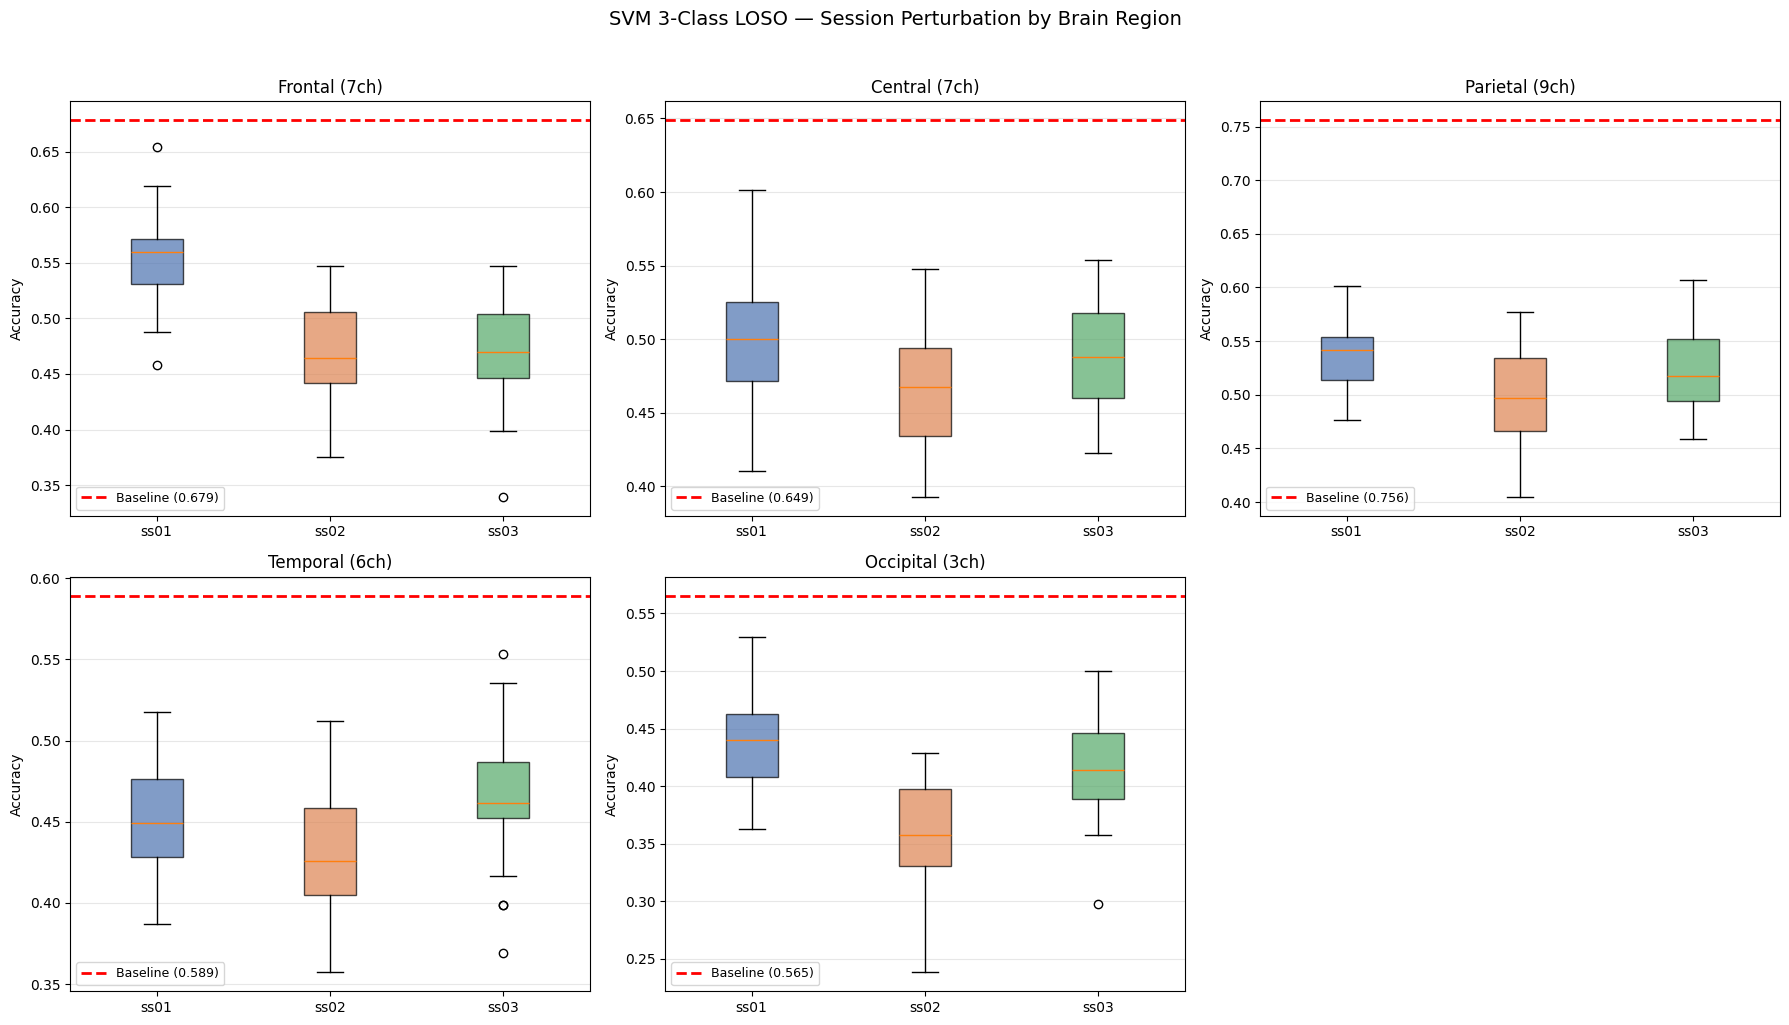

In [46]:
# ── 擾動效果視覺化：5 腦區 × 3 session ──

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (region_name, ch_idx) in enumerate(REGIONS.items()):
    ax = axes[idx]
    n_ch = len(ch_idx)
    b_acc = baseline[region_name]['acc']

    bp_data = [perturb_results[region_name][i]['accs'] for i in range(3)]
    bp = ax.boxplot(bp_data, labels=['ss01', 'ss02', 'ss03'],
                    patch_artist=True)
    colors = ['#4C72B0', '#DD8452', '#55A868']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(y=b_acc, color='red', linestyle='--', linewidth=2,
               label=f'Baseline ({b_acc:.3f})')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{region_name} ({n_ch}ch)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('SVM 3-Class LOSO — Session Perturbation by Brain Region', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_session_perturbation_region5_box.png',
            dpi=150, bbox_inches='tight')
plt.show()

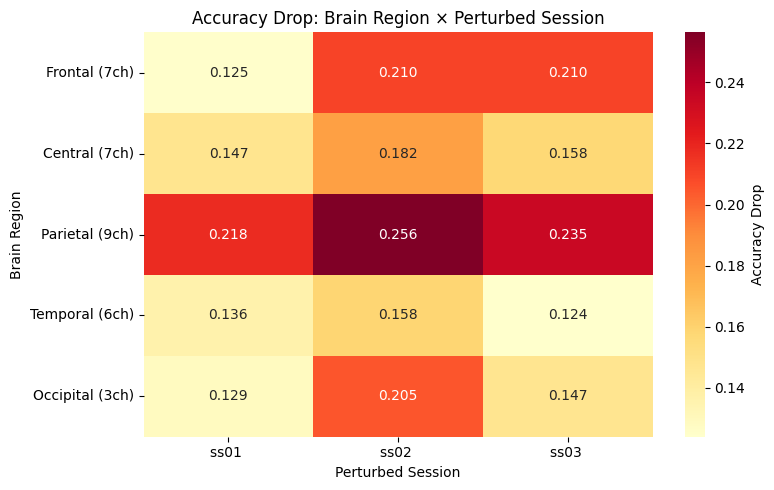

In [49]:
# ── Accuracy Drop heatmap: 5 腦區 × 3 session ──

region_names = list(REGIONS.keys())
drop_matrix = np.zeros((len(region_names), 3))

for i, rn in enumerate(region_names):
    for ss_idx in range(3):
        drop_matrix[i, ss_idx] = baseline[rn]['acc'] - np.mean(perturb_results[rn][ss_idx]['accs'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(drop_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=['ss01 ', 'ss02 ', 'ss03 '],
            yticklabels=[f'{rn} ({len(REGIONS[rn])}ch)' for rn in region_names],
            ax=ax, cbar_kws={'label': 'Accuracy Drop'})
ax.set_xlabel('Perturbed Session')
ax.set_ylabel('Brain Region')
ax.set_title('Accuracy Drop: Brain Region × Perturbed Session')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_session_perturbation_region5_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

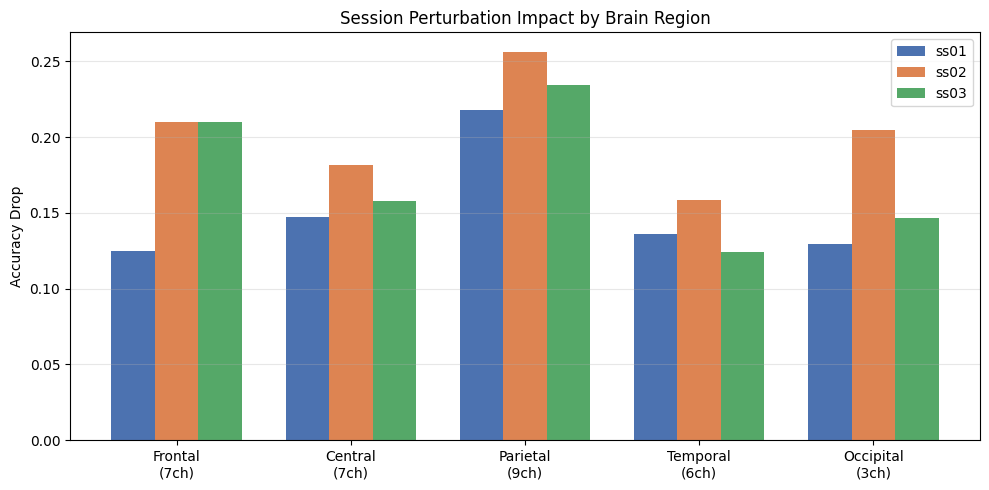

In [48]:
# ── Grouped bar chart: 每個腦區的 session drop 比較 ──

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(region_names))
width = 0.25
ss_colors = ['#4C72B0', '#DD8452', '#55A868']

for ss_idx in range(3):
    drops = [baseline[rn]['acc'] - np.mean(perturb_results[rn][ss_idx]['accs'])
             for rn in region_names]
    ax.bar(x + ss_idx * width, drops, width,
           label=SESSION_NAMES[ss_idx], color=ss_colors[ss_idx])

ax.set_xticks(x + width)
ax.set_xticklabels([f'{rn}\n({len(REGIONS[rn])}ch)' for rn in region_names])
ax.set_ylabel('Accuracy Drop')
ax.set_title('Session Perturbation Impact by Brain Region')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_session_perturbation_region5_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()